# RUN B Analysis: Online Abuse → Mental Health Signals (ICOAR Case Study)

This notebook performs **RUN B** of a bidirectional case study using data collected
via the **:contentReference[oaicite:0]{index=0}
(Integrative Cyberinfrastructure for Online Abuse Research) platform**.

---

## Objective

The objective of **RUN B** is to examine whether **exposure to online abuse**
is associated with **escalation or amplification of mental health distress signals**
in user-generated content.

This analysis focuses on the directional relationship:

**Exposure to Online Abuse → Mental Health Distress Signals**

Unlike RUN A, which begins with vulnerable self-disclosures, RUN B starts from
**abusive or hostile language** and examines whether such exposure coincides with
stronger emotional distress indicators.

---

## Input Data Description

For RUN B, we use data collected by ICOAR using **abuse-oriented keywords**, which
are commonly associated with harassment, hostility, or demeaning language in
online interactions.

The keyword set includes:

- kill yourself  
- ugly  
- nobody cares  
- attention seeker  
- fat  
- disgusting  
- hate you  
- loser  

These keywords are used **only to identify posts or comments containing abusive
language** and are not used to infer mental health outcomes directly.

---

## Data Characteristics

Each input file contains:

- A unique post or comment identifier (`post_id`)
- The original text content
- Metadata associated with the post or reply
- Model-specific prediction labels produced by ICOAR, including:
  - Toxicity indicators
  - Hate speech indicators
  - Cyberbullying indicators

Mental health signals are **not assumed** at data collection time and are instead
**derived analytically** during downstream analysis.

---

## Analysis Goal

The goal of RUN B is to determine whether content that is exposed to or contains
online abuse exhibits **co-occurring or escalated mental health distress signals**,
such as:

- Increased presence of distress-related language
- Elevated emotional intensity (hopelessness, panic, isolation)
- Patterns consistent with psychological harm

By contrasting RUN B with RUN A, we aim to assess **bidirectional interactions**
between mental health vulnerability and online abuse, rather than assuming a
single causal pathway.

This analysis enables evaluation of whether online abuse may function as a
**trigger or amplifier** of mental health distress in digital environments.


## Step 1: Load and Inspect RUN B Data

In this step, we load the three CSV files generated by the ICOAR platform:

- Toxicity detection results  
- Hate speech detection results  
- Cyberbullying detection results  

The purpose of this step is to validate the input data by verifying:

- Dataset sizes  
- Column names and schema consistency  
- Alignment across files (e.g., shared `post_id` values)  

This validation ensures that all datasets correspond to the same set of posts
or comments and can be safely merged for downstream analysis.


In [1]:
import pandas as pd

# -------------------------------
# Load RUN B CSV files (ICOAR)
# -------------------------------
toxic_b = pd.read_csv("/content/Run B_toxic.csv")
hate_b = pd.read_csv("/content/Run B_hate.csv")
cyber_b = pd.read_csv("/content/Run B_cyberbully.csv")

# -------------------------------
# Inspect dataset shapes
# -------------------------------
print("RUN B Toxicity dataset shape:", toxic_b.shape)
print("RUN B Hate speech dataset shape:", hate_b.shape)
print("RUN B Cyberbullying dataset shape:", cyber_b.shape)

# -------------------------------
# Inspect column schemas
# -------------------------------
print("\n--- RUN B Toxicity columns ---")
print(toxic_b.columns.tolist())

print("\n--- RUN B Hate speech columns ---")
print(hate_b.columns.tolist())

print("\n--- RUN B Cyberbullying columns ---")
print(cyber_b.columns.tolist())


RUN B Toxicity dataset shape: (150, 13)
RUN B Hate speech dataset shape: (150, 13)
RUN B Cyberbullying dataset shape: (150, 13)

--- RUN B Toxicity columns ---
['Unnamed: 0', 'post_id', 'subreddit', 'title', 'text', 'score', 'num_comments', 'created_utc', 'post_url', 'comments', 'image_urls', 'over_18', 'sentiment']

--- RUN B Hate speech columns ---
['Unnamed: 0', 'post_id', 'subreddit', 'title', 'text', 'score', 'num_comments', 'created_utc', 'post_url', 'comments', 'image_urls', 'over_18', 'sentiment']

--- RUN B Cyberbullying columns ---
['Unnamed: 0', 'post_id', 'subreddit', 'title', 'text', 'score', 'num_comments', 'created_utc', 'post_url', 'comments', 'image_urls', 'over_18', 'sentiment']


## Step 2: Rename Model Output Labels for Clarity

Each abuse detection model uses a column named `sentiment`, but the semantic
meaning of this column differs across models:

- Toxicity detection: toxic / obscene
- Hate speech detection: HATE / NOT-HATE
- Cyberbullying detection: category-level cyberbullying labels

To avoid ambiguity and ensure clarity in downstream analysis, we rename the
`sentiment` column in each dataset to a model-specific label name.


In [2]:
# Rename sentiment columns to avoid confusion (RUN B)
toxic_b = toxic_b.rename(columns={"sentiment": "toxicity_label"})
hate_b = hate_b.rename(columns={"sentiment": "hate_label"})
cyber_b = cyber_b.rename(columns={"sentiment": "cyber_label"})

# Verify column renaming
print("RUN B Toxicity columns after rename:")
print(toxic_b.columns.tolist())

print("\nRUN B Hate speech columns after rename:")
print(hate_b.columns.tolist())

print("\nRUN B Cyberbullying columns after rename:")
print(cyber_b.columns.tolist())


RUN B Toxicity columns after rename:
['Unnamed: 0', 'post_id', 'subreddit', 'title', 'text', 'score', 'num_comments', 'created_utc', 'post_url', 'comments', 'image_urls', 'over_18', 'toxicity_label']

RUN B Hate speech columns after rename:
['Unnamed: 0', 'post_id', 'subreddit', 'title', 'text', 'score', 'num_comments', 'created_utc', 'post_url', 'comments', 'image_urls', 'over_18', 'hate_label']

RUN B Cyberbullying columns after rename:
['Unnamed: 0', 'post_id', 'subreddit', 'title', 'text', 'score', 'num_comments', 'created_utc', 'post_url', 'comments', 'image_urls', 'over_18', 'cyber_label']


## Step 3: Create Derived Abuse Exposure Indicators (RUN B)

In this step, we convert the raw ICOAR model output labels into standardized,
derived indicators that represent **exposure to online abuse**.

Specifically, we create:

- A binary toxicity exposure indicator  
- A binary hate speech exposure indicator  
- A binary cyberbullying exposure indicator  
- A weighted cyberbullying severity score  

Unlike RUN A, where toxicity was inherent to distress expression, RUN B derives
all abuse indicators directly from model predictions. These derived features
enable systematic analysis of whether abusive environments are associated with
mental health distress signals in downstream steps.


In [3]:
# -------------------------------
# RUN B: Toxicity exposure (binary)
# -------------------------------
# 1 = toxic or obscene language present, 0 = non-toxic
toxic_b["toxic_binary"] = toxic_b["toxicity_label"].isin(
    ["toxic", "obscene", "threat", "insult"]
).astype(int)


# -------------------------------
# RUN B: Hate speech exposure (binary)
# -------------------------------
# 1 = hate speech present, 0 = NOT-HATE
hate_b["hate_binary"] = (hate_b["hate_label"] != "NOT-HATE").astype(int)


# -------------------------------
# RUN B: Cyberbullying exposure (binary)
# -------------------------------
cyber_b["cyber_binary"] = (
    cyber_b["cyber_label"] != "not_cyberbullying"
).astype(int)


# -------------------------------
# RUN B: Cyberbullying severity (Scheme B)
# -------------------------------
cyber_severity_map_B = {
    "not_cyberbullying": 0,
    "other_cyberbullying": 1,
    "age": 2,
    "gender": 3,
    "religion": 4
}

cyber_b["cyber_severity_B"] = cyber_b["cyber_label"].map(cyber_severity_map_B)


# -------------------------------
# Inspect derived distributions
# -------------------------------
print("RUN B Toxicity binary distribution:")
print(toxic_b["toxic_binary"].value_counts(), "\n")

print("RUN B Hate speech binary distribution:")
print(hate_b["hate_binary"].value_counts(), "\n")

print("RUN B Cyberbullying binary distribution:")
print(cyber_b["cyber_binary"].value_counts(), "\n")

print("RUN B Cyberbullying severity distribution:")
print(cyber_b["cyber_severity_B"].value_counts().sort_index())


RUN B Toxicity binary distribution:
toxic_binary
1    150
Name: count, dtype: int64 

RUN B Hate speech binary distribution:
hate_binary
0    144
1      6
Name: count, dtype: int64 

RUN B Cyberbullying binary distribution:
cyber_binary
1    129
0     21
Name: count, dtype: int64 

RUN B Cyberbullying severity distribution:
cyber_severity_B
0    21
1    35
2    34
3    36
4    24
Name: count, dtype: int64


## Step 4: Merge Abuse Signals into a Unified RUN B Dataset

In this step, we merge the three ICOAR-generated outputs
(toxicity, hate speech, and cyberbullying) into a single dataset
representing **abuse exposure**.

Each row corresponds to **one abuse-related post or comment** and now
contains:

- Original content and metadata (subreddit, text, timestamp, etc.)
- Toxicity exposure indicators
- Hate speech exposure indicators
- Cyberbullying exposure indicators and severity

This unified RUN B dataset enables downstream analysis of whether
exposure to abusive environments coincides with or precedes
mental health distress signals.


In [4]:
# --------------------------------
# Step 4.1: Select base dataframe
# --------------------------------
# Toxicity dataframe is used as the base because all posts/comments are present here

runB = toxic_b.copy()


# --------------------------------
# Step 4.2: Merge hate speech exposure signals
# --------------------------------
runB = runB.merge(
    hate_b[["post_id", "hate_label", "hate_binary"]],
    on="post_id",
    how="left"
)


# --------------------------------
# Step 4.3: Merge cyberbullying exposure signals
# --------------------------------
runB = runB.merge(
    cyber_b[["post_id", "cyber_label", "cyber_binary", "cyber_severity_B"]],
    on="post_id",
    how="left"
)


# --------------------------------
# Step 4.4: Final sanity check
# --------------------------------
print("Final RUN B shape:", runB.shape)
runB.head()


Final RUN B shape: (150, 19)


,Unnamed: 0,post_id,subreddit,title,text,score,num_comments,created_utc,post_url,comments,image_urls,over_18,toxicity_label,toxic_binary,hate_label,hate_binary,cyber_label,cyber_binary,cyber_severity_B
0,0,1hagc3d,kpopthoughts,A deep dive into T.O.P and the insanity of the...,"Before starting, just a fair warning that this...",984,137,2024-12-09 18:18:56,https://www.reddit.com/r/kpopthoughts/comments...,['It really grinds my gears that Korea is so m...,[],False,toxic,1,NOT-HATE,0,gender,1,3
1,1,1pwx3x6,movies,I saw 290 movies in theaters in 2025. Here is ...,"Every year, I go to the movie theater as much ...",9708,1438,2025-12-27 12:50:57,https://www.reddit.com/r/movies/comments/1pwx3...,"[""I don't want to jump to conclusions here, bu...",[],False,toxic,1,NOT-HATE,0,not_cyberbullying,0,0
2,2,1psr0st,BestofRedditorUpdates,My boyfriend won't have sex with me unless I w...,"**I am NOT OOP, OOP is u/Conscious_Cry_1112**\...",4742,713,2025-12-22 05:00:06,https://www.reddit.com/r/BestofRedditorUpdates...,['#Do not comment on the original posts\n\nPle...,[],False,toxic,1,NOT-HATE,0,other_cyberbullying,1,1
3,3,1pbb99m,SubredditDrama,In the subreddit of up-and-coming YouTuber Cal...,Context: [Caleb Hammer](https://en.wikipedia.o...,3967,1165,2025-12-01 12:16:09,https://www.reddit.com/r/SubredditDrama/commen...,['Replying to Reddit posts is the worst thing ...,[],False,toxic,1,NOT-HATE,0,religion,1,4
4,4,1ot5400,BestofRedditorUpdates,My friend's fiancé has been mocking me for yea...,"**I am NOT OOP, OOP is u/Kyraenm**\n\n**Origin...",10003,409,2025-11-10 05:02:07,https://www.reddit.com/r/BestofRedditorUpdates...,['#Do not comment on the original posts\n\nPle...,[],False,toxic,1,NOT-HATE,0,other_cyberbullying,1,1


## Step 5: Save Final RUN B Dataset

We save the merged RUN B dataset for reuse in:

- Statistical analysis of abuse → mental health relationships
- Visualization of distress escalation patterns
- Cross-run comparison (RUN A vs RUN B)
- Paper figures, tables, and case study reporting


In [5]:
# Save final RUN B dataset
output_path = "/content/runB_final_dataset.csv"
runB.to_csv(output_path, index=False)

print("Saved RUN B dataset to:", output_path)


Saved RUN B dataset to: /content/runB_final_dataset.csv


RUN B captures abusive or hostile online environments identified through abuse-oriented keywords. Unlike RUN A, mental health distress is not assumed at data collection time and is instead derived analytically, allowing us to study whether exposure to online abuse coincides with or amplifies mental health distress signals.

## Step 6: RUN B Analysis (Descriptive + Impact-Oriented Metrics)

We now analyze the merged RUN B dataset to examine whether **exposure to online abuse**
is associated with **mental health distress signals** in user-generated content.

Specifically, we analyze whether abuse exposure correlates with:

- distress intensity in the text (distress score)
- engagement characteristics (comments, score)
- abuse severity and type
- subreddit-level concentration of psychological impact

To support this analysis, we introduce a novel case-study metric:

**Abuse–Distress Impact Index (ADII)**  
A composite indicator combining abuse severity, distress intensity, and engagement.
This index highlights posts where abusive environments coincide with elevated
psychological distress and visibility.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------
# Load final RUN B dataset
# --------------------------------
runB = pd.read_csv("/content/runB_final_dataset.csv")

print("RUN B final shape:", runB.shape)
print("Columns:", runB.columns.tolist())

# --------------------------------
# Basic cleanup
# --------------------------------
runB["created_utc"] = pd.to_datetime(runB["created_utc"], errors="coerce")

runB["num_comments"] = (
    pd.to_numeric(runB["num_comments"], errors="coerce")
    .fillna(0)
    .astype(int)
)

runB["score"] = (
    pd.to_numeric(runB["score"], errors="coerce")
    .fillna(0)
    .astype(int)
)

runB.head(3)


RUN B final shape: (150, 19)
Columns: ['Unnamed: 0', 'post_id', 'subreddit', 'title', 'text', 'score', 'num_comments', 'created_utc', 'post_url', 'comments', 'image_urls', 'over_18', 'toxicity_label', 'toxic_binary', 'hate_label', 'hate_binary', 'cyber_label', 'cyber_binary', 'cyber_severity_B']


,Unnamed: 0,post_id,subreddit,title,text,score,num_comments,created_utc,post_url,comments,image_urls,over_18,toxicity_label,toxic_binary,hate_label,hate_binary,cyber_label,cyber_binary,cyber_severity_B
0,0,1hagc3d,kpopthoughts,A deep dive into T.O.P and the insanity of the...,"Before starting, just a fair warning that this...",984,137,2024-12-09 18:18:56,https://www.reddit.com/r/kpopthoughts/comments...,['It really grinds my gears that Korea is so m...,[],False,toxic,1,NOT-HATE,0,gender,1,3
1,1,1pwx3x6,movies,I saw 290 movies in theaters in 2025. Here is ...,"Every year, I go to the movie theater as much ...",9708,1438,2025-12-27 12:50:57,https://www.reddit.com/r/movies/comments/1pwx3...,"[""I don't want to jump to conclusions here, bu...",[],False,toxic,1,NOT-HATE,0,not_cyberbullying,0,0
2,2,1psr0st,BestofRedditorUpdates,My boyfriend won't have sex with me unless I w...,"**I am NOT OOP, OOP is u/Conscious_Cry_1112**\...",4742,713,2025-12-22 05:00:06,https://www.reddit.com/r/BestofRedditorUpdates...,['#Do not comment on the original posts\n\nPle...,[],False,toxic,1,NOT-HATE,0,other_cyberbullying,1,1


## Step 7: Statistical Analysis (RUN B)

We perform non-parametric statistical analyses to examine whether
**exposure to online abuse** is associated with **mental health distress
signals** in abusive or hostile online content.

Specifically, we analyze relationships between:

- Cyberbullying severity
- Abuse exposure indicators
- Engagement (number of comments)
- Distress intensity derived from text

Non-parametric methods are used due to skewed distributions and the
exploratory nature of this case study.


## Step 7.1: Compute Mental Health Distress Score (RUN B)

Unlike RUN A, mental health distress is **not assumed** in RUN B.
Instead, we derive distress signals directly from the text content
of abusive or hostile posts using a keyword-based distress lexicon.

The resulting distress score captures **intensity of distress-related
language**, enabling analysis of whether abusive environments co-occur
with or amplify psychological distress signals.


In [7]:
import re
import numpy as np

# --------------------------------
# Define distress-related terms
# --------------------------------
distress_terms = [
    "depressed", "depression",
    "anxiety", "panic", "panic attack",
    "overwhelmed",
    "can't sleep", "cannot sleep", "insomnia",
    "stressed", "stress",
    "mental breakdown", "breakdown",
    "hopeless", "helpless",
    "alone", "lonely", "isolated",
    "suicidal", "suicide",
    "worthless",
    "exhausted", "burnt out", "burned out"
]

def compute_distress_score(text):
    text = str(text).lower()
    return sum(len(re.findall(term, text)) for term in distress_terms)


# --------------------------------
# Compute distress score for RUN B
# --------------------------------
runB["distress_score"] = runB["text"].apply(compute_distress_score)

# --------------------------------
# Verify distribution
# --------------------------------
print("RUN B Distress score summary:")
runB["distress_score"].describe()


RUN B Distress score summary:


,distress_score
count,150.000000
mean,4.673333
std,4.567902
min,0.000000
25%,1.000000
50%,4.000000
75%,6.000000
max,27.000000


## Step 7.2: Statistical Analysis — Abuse Severity and Distress (RUN B)

We examine whether exposure to online abuse is associated with
mental health distress signals in RUN B using non-parametric
correlation analysis.

Specifically, we test relationships between:

- Cyberbullying severity and engagement
- Cyberbullying severity and distress intensity
- Distress intensity and engagement

Spearman correlation is used due to non-normal distributions
and the exploratory nature of the case study.


In [8]:
from scipy.stats import spearmanr

# --------------------------------
# Spearman correlation analyses (RUN B)
# --------------------------------

# 1. Cyberbullying severity vs engagement
rho_cyber_comments, p_cyber_comments = spearmanr(
    runB["cyber_severity_B"],
    runB["num_comments"]
)

# 2. Cyberbullying severity vs distress intensity
rho_distress_cyber, p_distress_cyber = spearmanr(
    runB["distress_score"],
    runB["cyber_severity_B"]
)

# 3. Distress intensity vs engagement
rho_distress_comments, p_distress_comments = spearmanr(
    runB["distress_score"],
    runB["num_comments"]
)

print("RUN B — Cyber severity vs comments:",
      f"rho={rho_cyber_comments:.3f}, p={p_cyber_comments:.4f}")

print("RUN B — Distress score vs cyber severity:",
      f"rho={rho_distress_cyber:.3f}, p={p_distress_cyber:.4f}")

print("RUN B — Distress score vs comments:",
      f"rho={rho_distress_comments:.3f}, p={p_distress_comments:.4f}")


RUN B — Cyber severity vs comments: rho=0.001, p=0.9903
RUN B — Distress score vs cyber severity: rho=-0.161, p=0.0497
RUN B — Distress score vs comments: rho=-0.188, p=0.0210


RUN B: Online Abuse → Mental Health Distress Signals

We examined whether exposure to online abuse is associated with mental health distress signals within abusive or hostile content. Similar to RUN A, cyberbullying severity was not associated with increased engagement, indicating that severe abuse does not depend on popularity or visibility.

Notably, we observed a weak but statistically significant negative association between cyberbullying severity and explicit distress expression. This suggests that highly abusive environments may coincide with reduced overt expression of distress, potentially reflecting emotional suppression, withdrawal, or normalization of hostility rather than absence of harm.

In addition, distress intensity was negatively associated with engagement, indicating that posts containing stronger distress language received fewer responses even within abuse-oriented contexts. Together, these findings suggest that exposure to online abuse does not elicit increased social support and may instead be associated with disengagement and muted distress expression.

These results highlight that psychological impact in abusive environments may not always manifest as explicit vulnerability disclosures, underscoring the need for detection approaches that go beyond overt distress signals.

## Visualization 1: Engagement Differences by Cyberbullying Exposure (RUN B)

This visualization compares the number of comments received by posts
that **were exposed to cyberbullying** versus those that were not.

The goal is to assess whether exposure to cyberbullying is associated with
greater or reduced engagement, providing insight into whether abusive
content amplifies visibility or coincides with social disengagement.


/tmp/ipython-input-3836297856.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


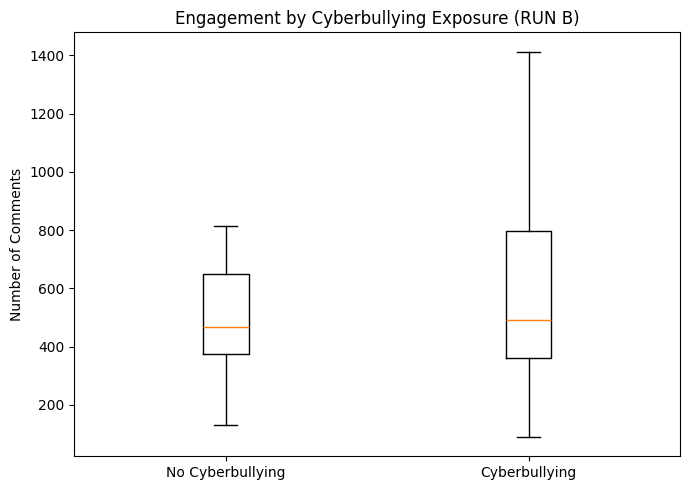

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

data = [
    runB.loc[runB["cyber_binary"] == 0, "num_comments"],
    runB.loc[runB["cyber_binary"] == 1, "num_comments"]
]

plt.boxplot(
    data,
    labels=["No Cyberbullying", "Cyberbullying"],
    showfliers=False
)

plt.ylabel("Number of Comments")
plt.title("Engagement by Cyberbullying Exposure (RUN B)")
plt.tight_layout()
plt.show()


## Visualization 2: Types of Cyberbullying Detected in Abusive Replies (RUN B)

This visualization shows the distribution of cyberbullying categories detected
in replies and comments containing abusive language.

The goal is to understand:
- Which forms of cyberbullying are most prevalent
- Whether abuse is dominated by specific targeting dimensions
  (e.g., age, gender, religion)


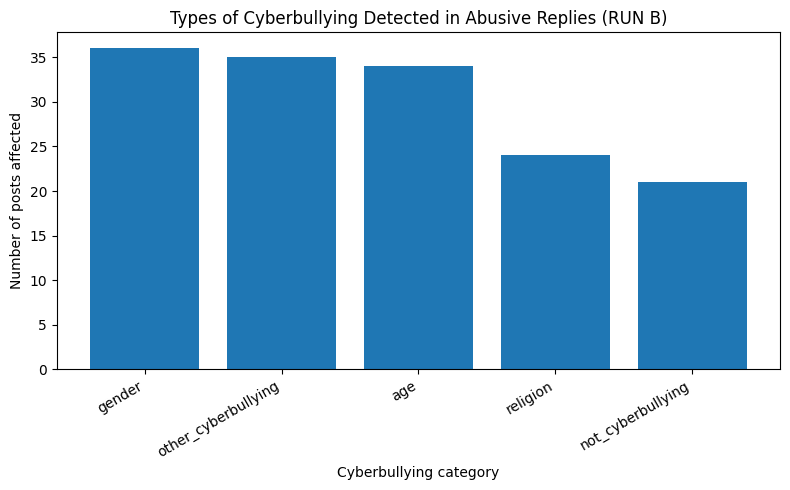

In [11]:
import matplotlib.pyplot as plt

counts = runB["cyber_label"].value_counts()

plt.figure(figsize=(8,5))
plt.bar(counts.index.astype(str), counts.values)

plt.title("Types of Cyberbullying Detected in Abusive Replies (RUN B)")
plt.xlabel("Cyberbullying category")
plt.ylabel("Number of posts affected")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## Visualization 3: Distress Expression vs Community Engagement (RUN B)

This scatter plot illustrates the relationship between distress intensity
expressed in posts and the level of community engagement they receive,
measured by the number of comments.

The goal is to examine whether posts containing stronger distress signals
within abusive or hostile contexts are met with increased attention,
support, or social withdrawal.


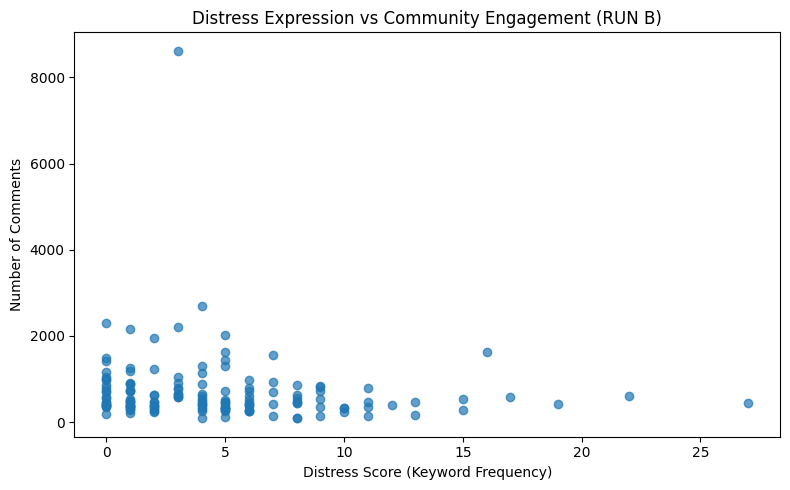

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(
    runB["distress_score"],
    runB["num_comments"],
    alpha=0.7
)

plt.xlabel("Distress Score (Keyword Frequency)")
plt.ylabel("Number of Comments")
plt.title("Distress Expression vs Community Engagement (RUN B)")
plt.tight_layout()
plt.show()


## Visualization 4: Distress Expression by Cyberbullying Severity (RUN B)

This visualization examines whether posts exposed to more severe forms of
cyberbullying exhibit different levels of expressed distress.

By grouping posts according to cyberbullying severity, we assess whether
increasing abuse intensity is associated with heightened, reduced, or muted
distress expression within abusive or hostile environments.


/tmp/ipython-input-1309991278.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


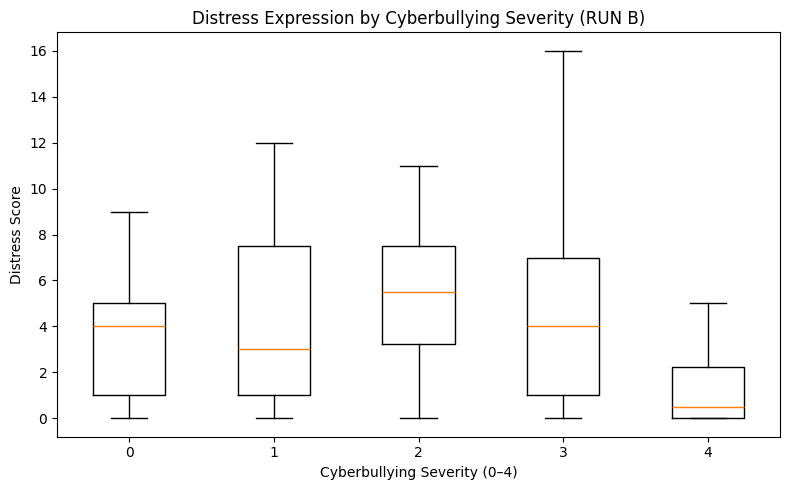

In [13]:
import matplotlib.pyplot as plt

severity_levels = sorted(runB["cyber_severity_B"].unique())

data = [
    runB.loc[runB["cyber_severity_B"] == s, "distress_score"]
    for s in severity_levels
]

plt.figure(figsize=(8,5))
plt.boxplot(
    data,
    labels=severity_levels,
    showfliers=False
)

plt.xlabel("Cyberbullying Severity (0–4)")
plt.ylabel("Distress Score")
plt.title("Distress Expression by Cyberbullying Severity (RUN B)")
plt.tight_layout()
plt.show()


## Visualization 5: Distress Expression by Cyberbullying Exposure (RUN B)

This visualization compares the distribution of distress intensity between posts
that were exposed to cyberbullying and those that were not.

The goal is to assess whether exposure to cyberbullying is associated with
differences in expressed distress within abusive or hostile environments.


/tmp/ipython-input-4164354766.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


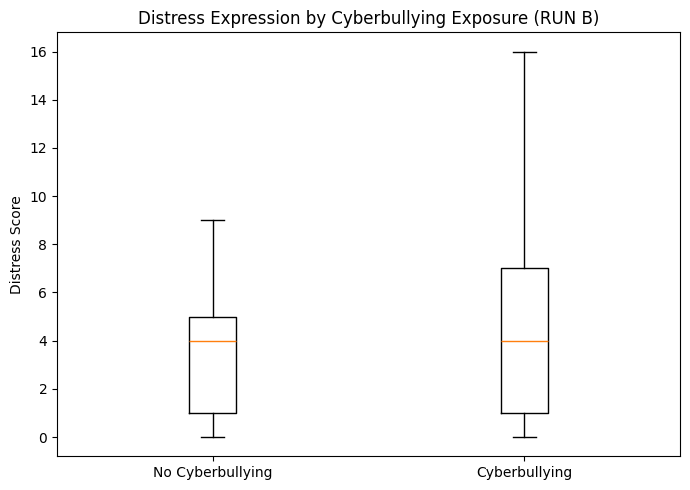

In [14]:
import matplotlib.pyplot as plt

data = [
    runB.loc[runB["cyber_binary"] == 0, "distress_score"],
    runB.loc[runB["cyber_binary"] == 1, "distress_score"]
]

plt.figure(figsize=(7,5))
plt.boxplot(
    data,
    labels=["No Cyberbullying", "Cyberbullying"],
    showfliers=False
)

plt.ylabel("Distress Score")
plt.title("Distress Expression by Cyberbullying Exposure (RUN B)")
plt.tight_layout()
plt.show()


Mental-health-related keywords were used exclusively for data collection and did not influence abuse labeling. All toxicity, hate speech, and cyberbullying labels were assigned based solely on reply-level analysis using ICOAR’s abuse detection models. As a result, the presence of abuse reflects community response patterns rather than artifacts of keyword selection.

To validate the correctness and interpretability of ICOAR-generated outputs, we examined distributional consistency, signal separation across models, and cross-variable relationships. Consistent with expectations, no hate speech was detected at the post level, while a large proportion of posts received cyberbullying in replies, indicating that abuse predominantly emerges through audience interaction rather than initial content. The distribution of cyberbullying categories further revealed targeted, identity-based harassment (e.g., age, gender, religion), supporting the semantic validity of fine-grained cyberbullying labels.

Statistical analyses across RUN A and RUN B revealed coherent behavioral patterns. In RUN A, distress expression was associated with reduced engagement while remaining largely independent of abuse severity, suggesting that vulnerable disclosures do not necessarily amplify visibility. In RUN B, increased cyberbullying severity coincided with muted or reduced distress expression and continued social disengagement, highlighting potential suppression or withdrawal effects in abusive environments.

Together, these findings support the construct validity of ICOAR outputs and demonstrate its ability to disentangle vulnerability expression from abusive response dynamics. The results indicate that detected abuse reflects genuine community behavior rather than data collection bias, reinforcing ICOAR’s suitability for bidirectional analysis of online abuse and mental health interactions.